## Regression: "diamonds" dataset

1. Load Data
2. Visualize data (EDA)
3. Clean data: remove columns and/or rows
4. X/y Split
5. train_test_split
6. Fill/Encode/Scale Data: apply this only to the training set, then use those same parameters to transform the test set (binary encoding, one-hot encoding, cyclic encoding)
7. Check Correlation Matrix on the scaled/encoded training data
8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting
9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
10. Train Final Model: Retrain the model on the entire training set using the best parameters found.
11. View Results: R2, mse, mae

In questo esempio, vogliamo stimare la variabile "price" che è il prezzo di un diamante in base a varie sue qualità (dimensione, colore, carati, etc.)

---

In [24]:
# 1. load data
import pandas as pd

df = pd.read_csv("regression_diamonds.csv")

In [25]:
#2. visualize data (EDA)
df

,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [26]:
# Controlliamo i tipi delle colonne e se ci sono valori nulli
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  object 
 3   color    53940 non-null  object 
 4   clarity  53940 non-null  object 
 5   depth    53902 non-null  float64
 6   table    53940 non-null  float64
 7   price    53940 non-null  int64  
 8   x        53940 non-null  float64
 9   y        53940 non-null  float64
 10  z        53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [27]:
# Per le colonne categoriche (tipo "object"),
# può essere utile fare un conteggio di ciascuna categoria:

cat_columns = ["cut", "color", "clarity"]
for col in cat_columns:
    print(df[col].value_counts())
    print()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64



In [28]:
# Controlliamo meglio se ci sono valori nulli
df.isna().sum()

id          0
carat       0
cut         0
color       0
clarity     0
depth      38
table       0
price       0
x           0
y           0
z           0
dtype: int64

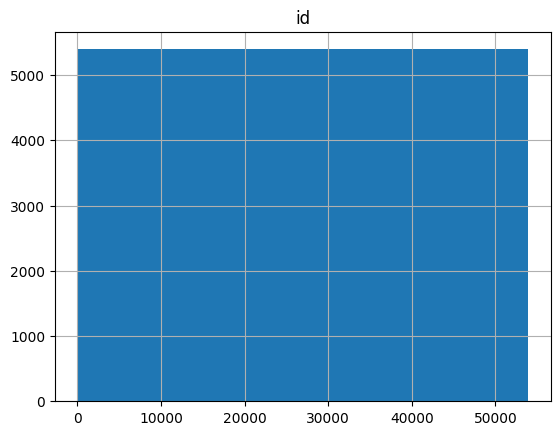

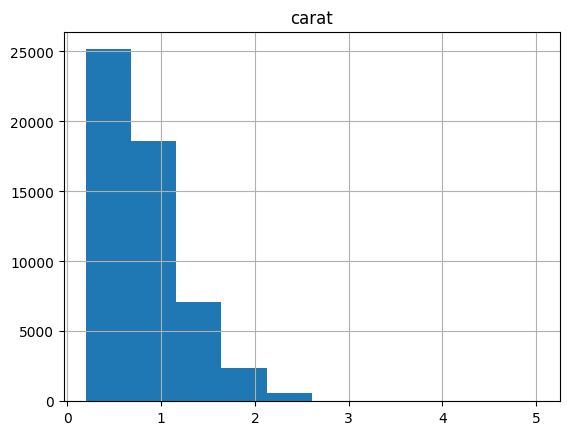

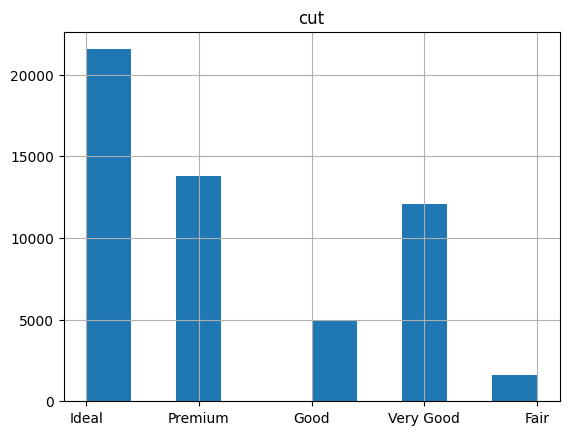

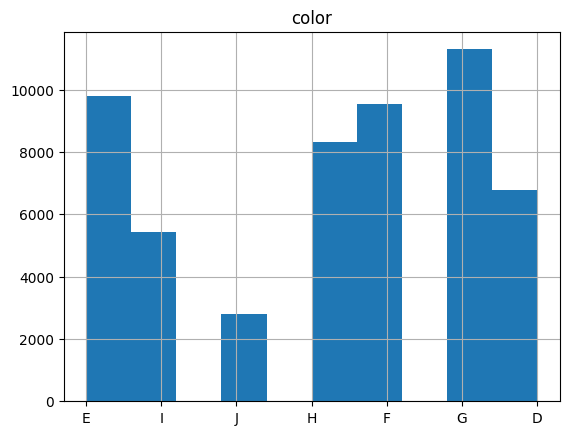

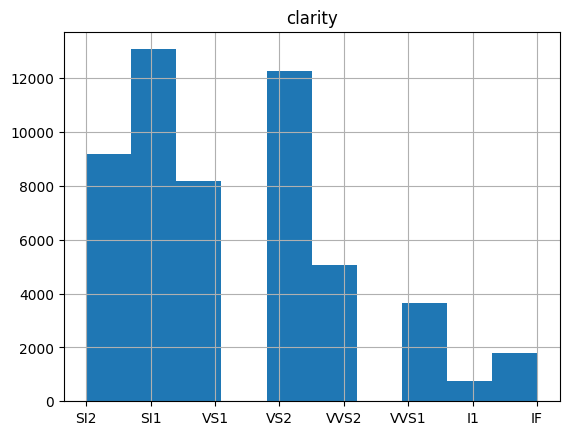

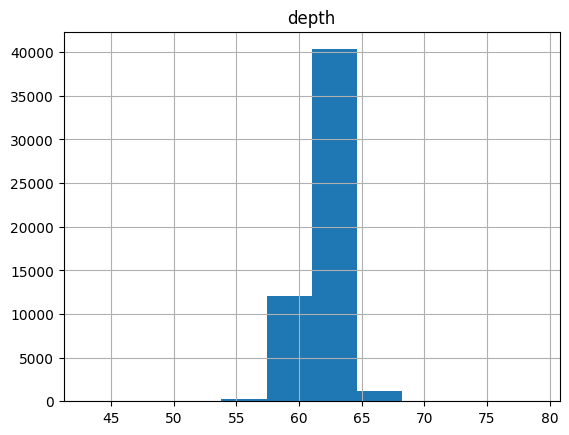

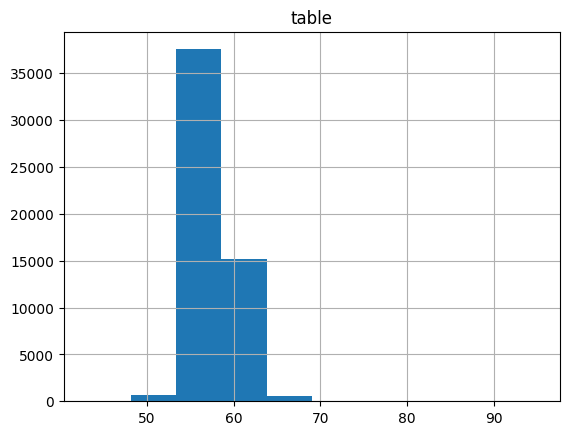

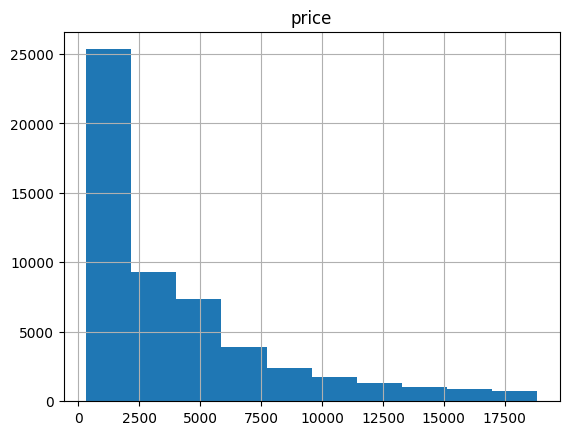

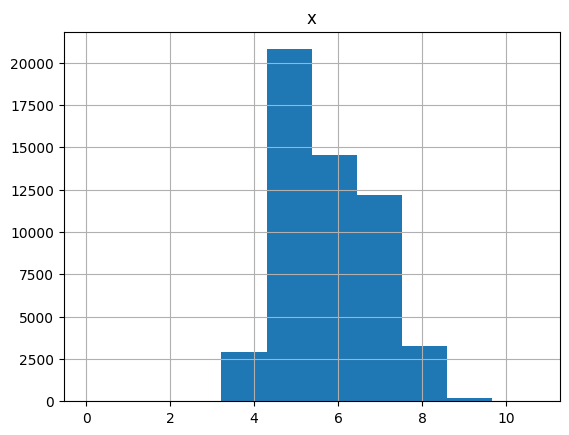

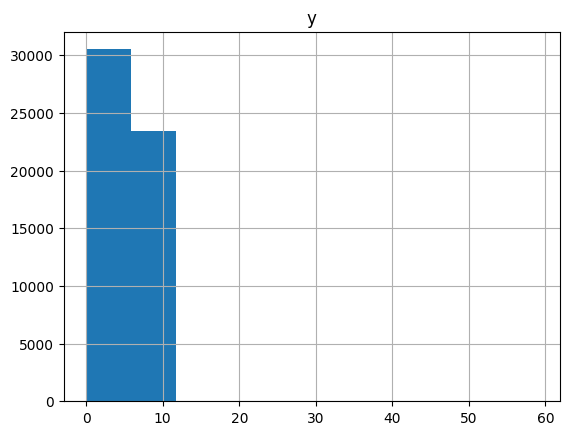

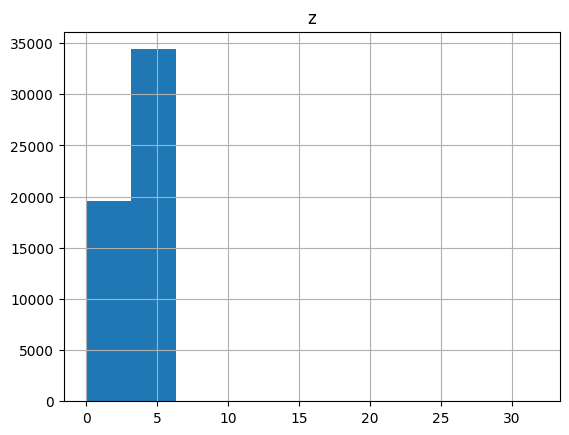

In [29]:
def plot_histograms(df):
    '''Print histogram for all columns'''
    import matplotlib.pyplot as plt
    for col in df.columns:
        plt.figure()
        df[col].hist()
        plt.title(col)
        plt.show()

plot_histograms(df)

In [30]:
# 3. Clean data: remove columns and/or rows

df_clean = df.copy()

# Remove entire 'id' column because it's irrelevant for predictions:
df_clean = df_clean.drop(columns=["id"])

# Remove rows with null values in a certain column:
# (skip this for now because we will be filling them with the column average)
# df_clean = df_clean.dropna(subset=["depth"])

df_clean

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [44]:
# 4. X/y Split

# 'price' è la variabile che dobbiamo stimare con il modello di regressione
y = df_clean["price"]
X = df_clean.drop(columns=["price"])

In [45]:
# 5. train_test_split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Dati di train:", len(X_train))
print("Dati di test:", len(X_test))

Dati di train: 43152
Dati di test: 10788


In [ ]:
# 6. Fill/Scale/Encode Data: apply this only to the training set, then use those same parameters to transform the test set

In [46]:
# In this dataset, the column 'depth' has some missing values:

# 35 missing values in the training set:
X_train.isna().sum()

carat       0
cut         0
color       0
clarity     0
depth      30
table       0
x           0
y           0
z           0
dtype: int64

In [47]:
# 3 missing values in the test set:
X_test.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      8
table      0
x          0
y          0
z          0
dtype: int64

In [48]:
# 6.1 Fill missing values using the mean/median/mode (must be calculated from the training set only)

X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

average_depth = X_train_filled["depth"].mean()

X_train_filled["depth"] = X_train_filled["depth"].fillna(average_depth) # Fill the column on the TRAIN set
X_test_filled["depth"] = X_test_filled["depth"].fillna(average_depth)   # Fill the column on the TEST set

# Check that there are no more missing values
X_train_filled.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

In [53]:
# 6.2 Encode a column manually

X_train_encoded = X_train_filled.copy()
X_test_encoded = X_test_filled.copy()

# Encode "cut" column

cut_encoding = {
  'Ideal': 5,
  'Premium': 4,
  'Very Good': 3,
  'Good': 2,
  'Fair': 1,
}

X_train_encoded['cut'] = X_train_encoded['cut'].map(cut_encoding)
X_test_encoded['cut'] = X_test_encoded['cut'].map(cut_encoding)

# Encode "clarity column"

clarity_encoding = {
  'IF': 8,
  'VVS1': 7,
  'VVS2': 6,
  'VS1': 5,
  'VS2': 4,
  'SI1': 3,
  'SI2': 2,
  'I1': 1,
}

X_train_encoded['clarity'] = X_train_encoded['clarity'].map(clarity_encoding)
X_test_encoded['clarity'] = X_test_encoded['clarity'].map(clarity_encoding)

X_train_encoded

,carat,cut,color,clarity,depth,table,x,y,z
49321,0.51,4,F,6,60.5,59.0,5.15,5.17,3.12
27323,2.01,4,H,3,61.3,59.0,8.16,8.08,4.98
36025,0.45,5,H,3,61.6,56.0,4.94,4.96,3.05
26555,2.20,3,H,4,63.3,58.0,8.25,8.22,5.21
41248,0.56,4,G,2,60.0,60.0,5.48,5.42,3.11
...,...,...,...,...,...,...,...,...,...
7207,0.91,3,E,3,58.8,59.0,6.34,6.39,3.74
27135,2.54,5,G,2,62.7,56.0,8.75,8.67,5.46
41977,0.55,5,F,2,62.4,56.0,5.26,5.22,3.27
3436,0.90,4,H,3,62.6,58.0,6.12,6.08,3.82


In [55]:
# Use one-hot encoding to encode a categorical column
# This is an alternative to ordinal encoding for non-ordered categories
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(X_train: pd.DataFrame, X_test: pd.DataFrame, columns_to_encode: list[str]) -> tuple[pd.DataFrame]:
    """Applies one-hot encoding to the specified columns"""

    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()

    one_hot_encoder = OneHotEncoder(
        sparse_output=False,  # Output a full matrix of 0 and 1 instead of a lightweight "sparse" matrix of just ones
        handle_unknown="ignore",
    ).set_output(transform="pandas") # Otherwise the encoder outputs a numpy array instead of a pandas dataframe

    new_encoded_columns = one_hot_encoder.fit_transform(X_train_encoded[columns_to_encode])

    # Add the new columns to the original TRAIN dataframe
    X_train_encoded = pd.concat(
        [
            X_train_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )

    # Add the new columns to the original dataframe
    new_encoded_columns = one_hot_encoder.transform(X_test_encoded[columns_to_encode])
    X_test_encoded = pd.concat(
        [
            X_test_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )  # Add the new columns to the original TEST dataframe

    # Remove original unencoded columns
    X_train_encoded = X_train_encoded.drop(columns=columns_to_encode)
    X_test_encoded = X_test_encoded.drop(columns=columns_to_encode)

    return X_train_encoded, X_test_encoded


X_train_1h_encoded, X_test_1h_encoded = one_hot_encode(X_train_encoded, X_test_encoded, columns_to_encode=["color"])

# Print result
X_train_1h_encoded

,carat,cut,clarity,depth,table,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.51,4,6,60.5,59.0,5.15,5.17,3.12,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2.01,4,3,61.3,59.0,8.16,8.08,4.98,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.45,5,3,61.6,56.0,4.94,4.96,3.05,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2.20,3,4,63.3,58.0,8.25,8.22,5.21,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.56,4,2,60.0,60.0,5.48,5.42,3.11,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43147,0.91,3,3,58.8,59.0,6.34,6.39,3.74,0.0,1.0,0.0,0.0,0.0,0.0,0.0
43148,2.54,5,2,62.7,56.0,8.75,8.67,5.46,0.0,0.0,0.0,1.0,0.0,0.0,0.0
43149,0.55,5,2,62.4,56.0,5.26,5.22,3.27,0.0,0.0,1.0,0.0,0.0,0.0,0.0
43150,0.90,4,3,62.6,58.0,6.12,6.08,3.82,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [56]:
# 6.3 Scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_1h_encoded)
X_test_scaled = scaler.transform(X_test_1h_encoded)

X_train_scaled

,carat,cut,clarity,depth,table,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,-0.609783,0.089199,1.180270,-0.868811,0.684511,-0.520624,-0.496535,-0.593295,-0.377924,-0.472072,2.151684,-0.516303,-0.424321,-0.333754,-0.233936
1,2.538183,0.089199,-0.635215,-0.313306,0.684511,2.152765,2.042283,2.022672,-0.377924,-0.472072,-0.464752,-0.516303,2.356708,-0.333754,-0.233936
2,-0.735702,0.983093,-0.635215,-0.104991,-0.654264,-0.707139,-0.679749,-0.691745,-0.377924,-0.472072,-0.464752,-0.516303,2.356708,-0.333754,-0.233936
3,2.936925,-0.804696,-0.030053,1.075458,0.238253,2.232700,2.164426,2.346152,-0.377924,-0.472072,-0.464752,-0.516303,2.356708,-0.333754,-0.233936
4,-0.504851,0.089199,-1.240377,-1.216002,1.130770,-0.227528,-0.278424,-0.607359,-0.377924,-0.472072,-0.464752,1.936847,-0.424321,-0.333754,-0.233936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43147,0.229674,-0.804696,-0.635215,-2.049260,0.684511,0.536297,0.567849,0.278694,-0.377924,2.118321,-0.464752,-0.516303,-0.424321,-0.333754,-0.233936
43148,3.650464,0.983093,-1.240377,0.658829,-0.654264,2.676785,2.557026,2.697760,-0.377924,-0.472072,-0.464752,1.936847,-0.424321,-0.333754,-0.233936
43149,-0.525837,0.983093,-1.240377,0.450514,-0.654264,-0.422925,-0.452913,-0.382330,-0.377924,-0.472072,2.151684,-0.516303,-0.424321,-0.333754,-0.233936
43150,0.208688,0.089199,-0.635215,0.589390,0.238253,0.340900,0.297391,0.391209,-0.377924,-0.472072,-0.464752,-0.516303,2.356708,-0.333754,-0.233936


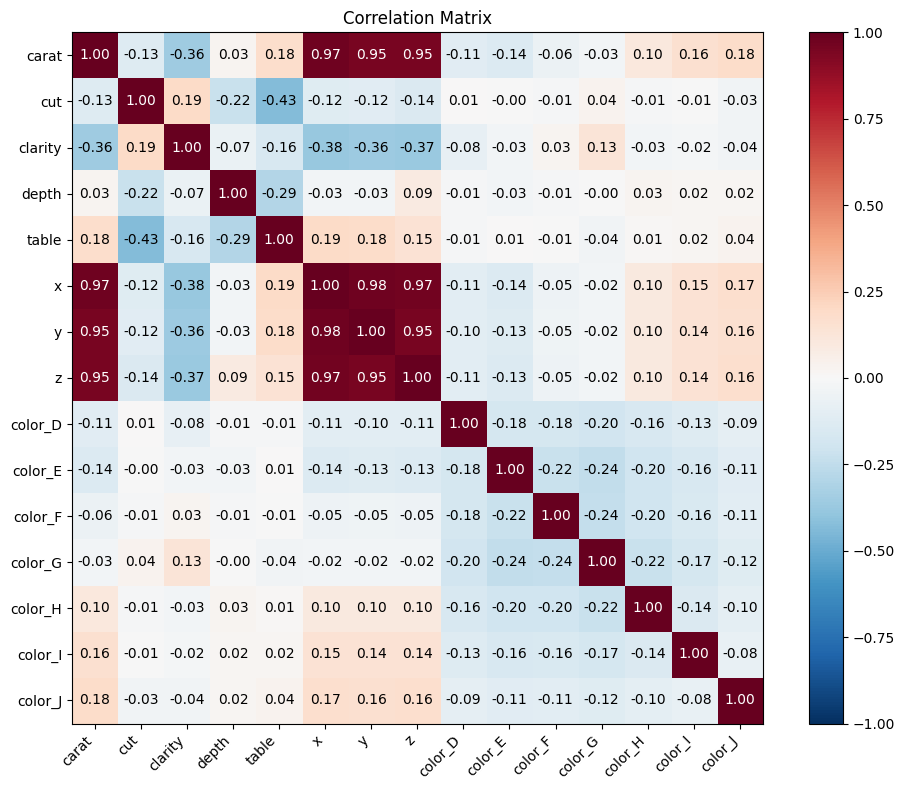

In [57]:
# 7. Check Correlation Matrix on the scaled/encoded training data


def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

show_correlation_matrix(X_train_scaled)

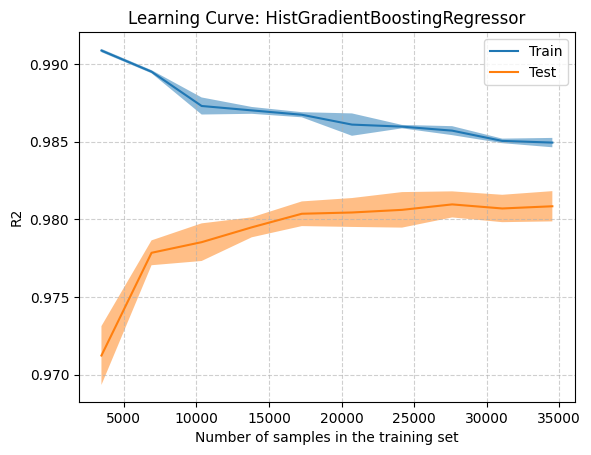

In [58]:
# 8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting

from sklearn.ensemble import HistGradientBoostingRegressor

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """
    import matplotlib.pyplot as plt
    from sklearn.model_selection import LearningCurveDisplay
    import numpy as np

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()


model = HistGradientBoostingRegressor()
plot_learning_curve(model, X_train_scaled, y_train, classification=False)

In [60]:
# 9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)

from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0, 5.0],
    'early_stopping': [True],
}

grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 5.0, 'max_iter': 200, 'max_leaf_nodes': 63, 'min_samples_leaf': 50}
Best score: 0.9810654978975194


In [61]:
# 10. Train Final Model: Retrain the model on the entire training set using the best parameters found

best_params = {'early_stopping': True, 'l2_regularization': 5.0, 'max_iter': 200, 'max_leaf_nodes': 63, 'min_samples_leaf': 50}

best_model = HistGradientBoostingRegressor(**best_params) # Pass a dictionary as parameters
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

In [62]:
# 11. View Results: use the test set to generate your scores: R2, mse, mae

def get_regression_metrics(y_test, y_pred) -> pd.DataFrame:
    """Calculates regression metrics"""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
    metrics = {
        "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred),
            root_mean_squared_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
    return pd.DataFrame(metrics).style.format({ "Value": "{:,.2f}" }) # Round to 2 decimals

get_regression_metrics(y_test, y_pred)

,Metric,Value
0,MAE,269.64
1,MSE,"286,637.09"
2,RMSE,535.38
3,R2 Score,0.98
